In [1]:
import os
from pathlib import Path

# ── Config ────────────────────────────────────────────────
DATA_ROOT = Path("")
IMAGES_DIR = DATA_ROOT / "images"
MASKS_DIR = DATA_ROOT / "masks"

IMG_SIZE = 256
# ──────────────────────────────────────────────────────────

image_files = sorted(os.listdir(IMAGES_DIR))
mask_files = sorted(os.listdir(MASKS_DIR))

print(f"Found {len(image_files)} images")
print(f"Found {len(mask_files)} masks")
print("Sample image filenames:", image_files[:5])
print("Sample mask filenames:", mask_files[:5])

Found 5108 images
Found 5108 masks
Sample image filenames: ['10452_sat_08.jpg', '10452_sat_18.jpg', '111335_sat_00.jpg', '111335_sat_01.jpg', '111335_sat_02.jpg']
Sample mask filenames: ['10452_mask_08.jpg', '10452_mask_18.jpg', '111335_mask_00.jpg', '111335_mask_01.jpg', '111335_mask_02.jpg']


In [2]:
def mask_name_to_image_name(mask_filename):
    """Converts '855_mask_01.jpg' -> '855_sat_01.jpg'."""
    return mask_filename.replace("_mask", "_sat")

# Quick check on the first 5 pairs
for m in mask_files[:5]:
    expected_image = mask_name_to_image_name(m)
    exists = expected_image in image_files
    print(f"{m}  ->  {expected_image}   (found: {exists})")

10452_mask_08.jpg  ->  10452_sat_08.jpg   (found: True)
10452_mask_18.jpg  ->  10452_sat_18.jpg   (found: True)
111335_mask_00.jpg  ->  111335_sat_00.jpg   (found: True)
111335_mask_01.jpg  ->  111335_sat_01.jpg   (found: True)
111335_mask_02.jpg  ->  111335_sat_02.jpg   (found: True)


In [3]:
# Full-dataset check: confirm every mask has a matching image
missing = []
for m in mask_files:
    expected_image = mask_name_to_image_name(m)
    if expected_image not in image_files:
        missing.append((m, expected_image))

print(f"Total masks: {len(mask_files)}")
print(f"Missing matches: {len(missing)}")
if missing:
    print("First few missing pairs:", missing[:5])

Total masks: 5108
Missing matches: 0


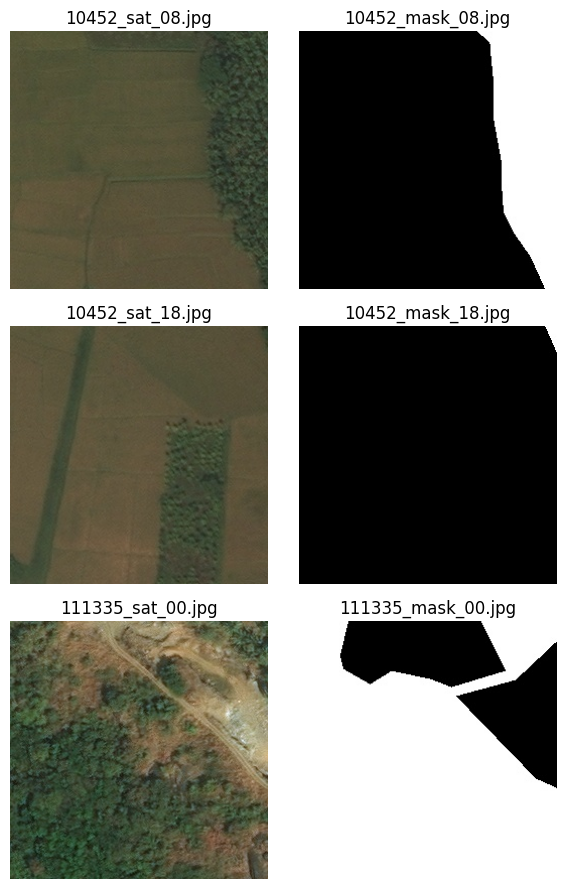

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

def show_pairs(mask_filenames, n=3):
    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n))

    for i, mask_fname in enumerate(mask_filenames[:n]):
        image_fname = mask_name_to_image_name(mask_fname)

        image = Image.open(IMAGES_DIR / image_fname).convert("RGB")
        mask = Image.open(MASKS_DIR / mask_fname).convert("L")

        axes[i, 0].imshow(image)
        axes[i, 0].set_title(image_fname)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title(mask_fname)
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

show_pairs(mask_files, n=3)

In [5]:
import numpy as np
import torch
from torch.utils.data import Dataset

class ForestSegDataset(Dataset):
    def __init__(self, mask_filenames, images_dir, masks_dir, img_size=256):
        self.mask_filenames = mask_filenames
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.img_size = img_size

        # ImageNet normalization stats (what SegFormer's pretrained backbone expects)
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.mask_filenames)

    def __getitem__(self, idx):
        mask_fname = self.mask_filenames[idx]
        image_fname = mask_name_to_image_name(mask_fname)

        image = Image.open(self.images_dir / image_fname).convert("RGB")
        image = image.resize((self.img_size, self.img_size))

        mask = Image.open(self.masks_dir / mask_fname).convert("L")
        mask = mask.resize((self.img_size, self.img_size), resample=Image.NEAREST)

        # Normalize image
        image = np.array(image, dtype=np.float32) / 255.0
        image = (image - self.mean) / self.std
        image = torch.from_numpy(image).permute(2, 0, 1).float()  # H,W,C -> C,H,W

        # Binarize mask: white (>127) = forest = 1, black = non-forest = 0
        mask = np.array(mask, dtype=np.int64)
        mask = (mask > 127).astype(np.int64)
        mask = torch.from_numpy(mask).long()

        return image, mask

In [6]:
dataset = ForestSegDataset(mask_files, IMAGES_DIR, MASKS_DIR, img_size=IMG_SIZE)

image_tensor, mask_tensor = dataset[0]

print("Image tensor shape:", image_tensor.shape, image_tensor.dtype)
print("Mask tensor shape:", mask_tensor.shape, mask_tensor.dtype)
print("Mask unique values:", torch.unique(mask_tensor))
print("Image value range:", image_tensor.min().item(), "to", image_tensor.max().item())

Image tensor shape: torch.Size([3, 256, 256]) torch.float32
Mask tensor shape: torch.Size([256, 256]) torch.int64
Mask unique values: tensor([0, 1])
Image value range: -1.6555356979370117 to -0.21498596668243408


In [ ]:
# ── Step 4: Load SegFormer-B0 and sanity-check one forward pass ──────────

from transformers import SegformerForSemanticSegmentation
import torch.nn.functional as F

# We start from a backbone pretrained on ImageNet ("nvidia/mit-b0"), but with
# a FRESH segmentation head on top, since our task (forest vs non-forest)
# has different classes than whatever the original model was trained for.
# num_labels=2 -> class 0 = non-forest, class 1 = forest
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=2,
    id2label={0: "non_forest", 1: "forest"},
    label2id={"non_forest": 0, "forest": 1},
)

# Use GPU if available, otherwise fall back to CPU (slower, but fine for
# this small local test with a few images)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print(f"Model loaded successfully. Running on: {device}")

config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

c:\Users\ADMIN\.conda\envs\tensorflow_env\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--nvidia--mit-b0. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 14.4MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.bias                                         | UNEXPECTED | 
classifier.weight                                       | UNEXPECTED | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.batch_norm.running_var                      

Model loaded successfully. Running on: cpu


model.safetensors: reconstructing file:   0%|          |  0.00B / 14.3MB            

model.safetensors: downloading bytes:           |  0.00B            

In [8]:
# ── Test: push ONE real image through the model and inspect the output ──

# Grab a single (image, mask) pair from the dataset we built in Step 3
image_tensor, mask_tensor = dataset[0]

# The model expects a BATCH of images, shaped (batch_size, channels, H, W).
# Our single image is (3, 256, 256) -- add a batch dimension of 1 in front.
image_batch = image_tensor.unsqueeze(0).to(device)   # -> (1, 3, 256, 256)
mask_batch = mask_tensor.unsqueeze(0).to(device)     # -> (1, 256, 256)

print("Input image batch shape:", image_batch.shape)

# Run the forward pass. We don't need gradients for this test -- we're just
# checking shapes, not training -- so wrap it in no_grad() to save memory.
with torch.no_grad():
    outputs = model(pixel_values=image_batch)

# outputs.logits is the model's raw prediction, BEFORE upsampling.
# SegFormer predicts at 1/4 resolution internally (a known quirk of the
# architecture), so expect H/4 x W/4, not the full 256x256 yet.
print("Raw output logits shape:", outputs.logits.shape)
# Expected: torch.Size([1, 2, 64, 64])
#            ^batch  ^classes ^height/4 ^width/4

Input image batch shape: torch.Size([1, 3, 256, 256])
Raw output logits shape: torch.Size([1, 2, 64, 64])


In [9]:
# ── Upsample the output back to full mask resolution and compare shapes ──

logits_upsampled = F.interpolate(
    outputs.logits,
    size=mask_batch.shape[-2:],   # target: (256, 256), matching our real mask
    mode="bilinear",
    align_corners=False,
)

print("Upsampled logits shape:", logits_upsampled.shape)
print("Ground truth mask shape:", mask_batch.shape)
# These two should now be directly comparable for computing loss in Step 5

Upsampled logits shape: torch.Size([1, 2, 256, 256])
Ground truth mask shape: torch.Size([1, 256, 256])
